### Imports 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from optic.models.tx import pamTransmitter
from optic.models.devices import photodiode, edfa, dac, adc, mzm, basicLaserModel
from optic.dsp.equalization import dfe, ffe
from optic.models.channels import linearFiberChannel, awgn
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc, theoryBER
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate ,signalPower
from optic.utils import parameters, dBm2W, lin2dB
from optic.plot import eyediagram, pconst
from scipy.special import erfc
import optic.comm.modulation as mod
from numpy.random import normal
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import k as kB



sys.path.append(os.path.abspath(os.path.join('..')))

c:\Users\elmer.farias\anaconda3\Lib\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [3]:
from AnalyticalSNR import (
    superGauss,
    SNR_Folding,
    SNR_DFE,
    SNR_FFE,
    calc_S_th,
    calc_S_th_opticompy,
    calc_S_shot,
    calc_S_shot_opticompy,
    calc_S_RIN,
    calc_S_RIN_opticompy,
    calc_S_ADC,
    calc_S_ADC_opticompy,
    calc_S_N,
    calculate_oma_outer,
    get_spectral_snr,
    ber_from_snr_m_pam,
    calculate_ps2
)

## Simple IMDD Transceiver Model 

![Texto Alternativo](images/model.png)


=== Resultados Calibrados (Pós-MZM) ===
Potência CW do Laser ajustada: 3.01 dBm
Potência Média do Sinal (P_TX): 0.00 dBm (1.000 mW)
ER obtido:    6.00 dB
OMA obtido:   1.197 mW (0.78 dBm)


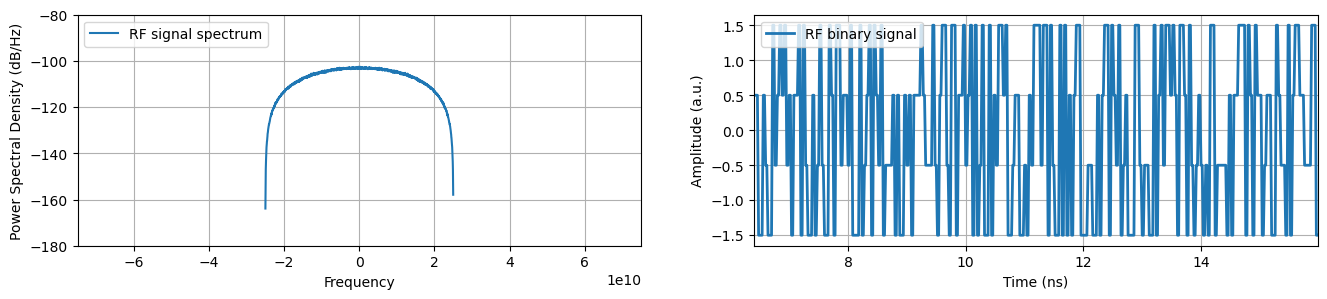

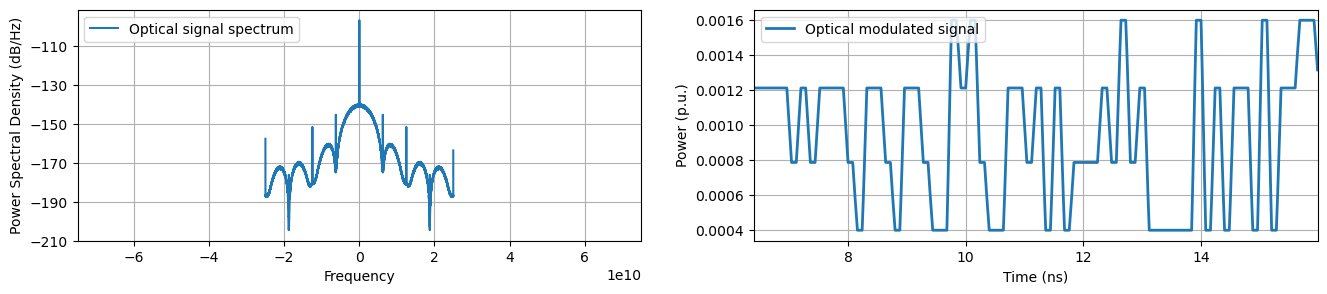

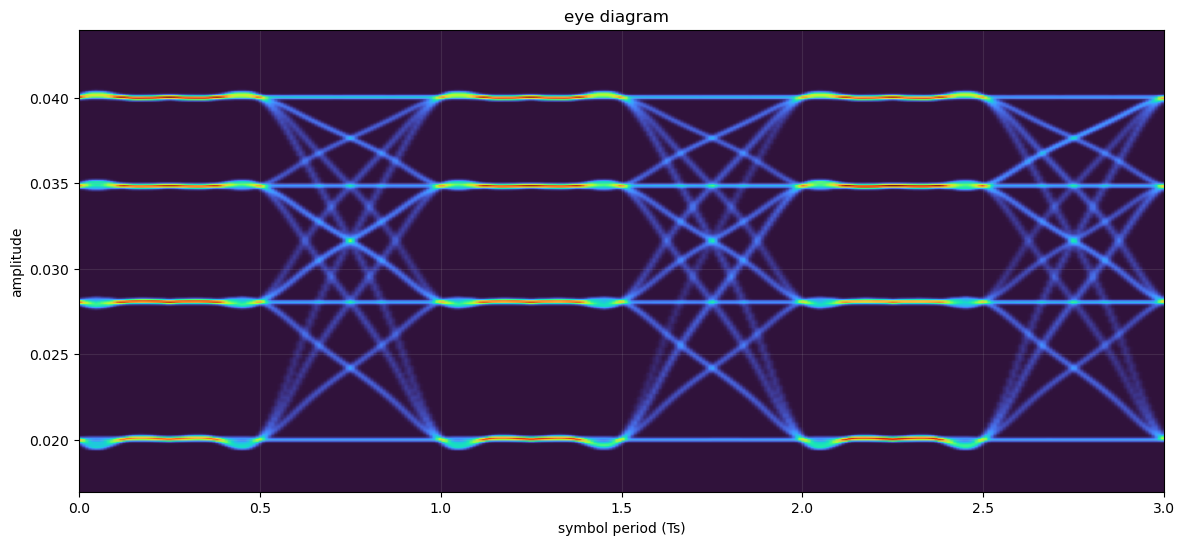

In [4]:
# Rate Sybol
Rs= 25e9
ER_lin = 10**(6/10)
P_avg_alvo = 1.0

#Sample Per Symbol
SpS= 2

# Sample Rate
Fs= Rs*SpS
#n_dac = 16
n_dac = 4
#Res = 16
Res= 8
DAC_ADC = True

#Sample Time
Ts= 1/Fs

#Modulation Order
M= 4

#Parameters for Bits Generation
paramBits =  parameters()
paramBits.nBits = 1000000
paramBits.mode= 'random'
paramBits.seed = 7
bits = bitSource(paramBits)

#Parameters for Modulation
symb_Tx= modulateGray(bits, M, 'pam')
symb_Tx_up = upsample(symb_Tx, SpS)

#Parameters for Pulse Shaping
paramPulse = parameters()
paramPulse.pulseType = 'rect'
paramPulse.SpS = SpS
pulse = pulseShape(paramPulse)

#Transmit Signal after Pulse Shaping
signal_Tx = firFilter(pulse, symb_Tx_up)

x = (ER_lin - 1) / (ER_lin + 1)
paramMZM = parameters()
paramMZM.Vpi = 8
paramMZM.Vb= -paramMZM.Vpi/2
Vpp_calculado = (2 * paramMZM.Vpi / np.pi) * np.arcsin(x)

#DAC Parameters
paramDAC = parameters()
paramDAC.inFs = Fs            # Frequência de entrada (igual a Rs = 25e9)
paramDAC.outFs = n_dac*Fs        # Frequência de saída da simulação (Rs * SpS = 400e9)
paramDAC.nBits = Res         # Resolução nominal alta para emular DAC ideal
paramDAC.ENOB = paramDAC.nBits           # Bits efetivos ideais (sem ruído térmico no DAC)
paramDAC.Vpp = Vpp_calculado           # Tensão pico a pico elétrica normalizada
paramDAC.AIF = True         # Filtro Anti-Imagem desligado (evita filtro redundante)

if(DAC_ADC):
    signal_Tx_DAC = dac(signal_Tx, paramDAC)
else:
    paramDAC.outFs = Fs
    signal_Tx_DAC = signal_Tx

E_unit = mzm(1.0 + 0j, signal_Tx_DAC, paramMZM)
P_avg_unit = np.mean(np.abs(E_unit)**2) 

# Multiplicamos o laser pelo inverso da atenuação para que a média final seja 1 mW
Pi_necessaria_mW = P_avg_alvo / P_avg_unit
Pi_dBm_calibrado = 10 * np.log10(Pi_necessaria_mW)

paramLaser = parameters()
paramLaser.P = Pi_dBm_calibrado
paramLaser.lw = 0
paramLaser.RIN_var = 1e-14
paramLaser.Fs= paramDAC.outFs
paramLaser.Ns = len(signal_Tx_DAC)
laserTx = basicLaserModel(paramLaser)



signal_optTx= mzm(laserTx, signal_Tx_DAC, paramMZM)

P_opt = np.abs(signal_optTx)**2
idx_p3 = signal_Tx_DAC > 0.95 * np.max(signal_Tx_DAC)
idx_p0 = signal_Tx_DAC < 0.95 * np.min(signal_Tx_DAC)

P_avg_sim = np.mean(P_opt)
P3_sim = np.mean(P_opt[idx_p3])
P0_sim = np.mean(P_opt[idx_p0])
OMA_sim = P3_sim - P0_sim
ER_sim_dB = 10 * np.log10(P3_sim / P0_sim)

print("=== Resultados Calibrados (Pós-MZM) ===")
print(f"Potência CW do Laser ajustada: {Pi_dBm_calibrado:.2f} dBm")
print(f"Potência Média do Sinal (P_TX): {10*np.log10(P_avg_sim*1e3):.2f} dBm ({P_avg_sim*1e3:.3f} mW)")
print(f"ER obtido:    {ER_sim_dB:.2f} dB")
print(f"OMA obtido:   {OMA_sim*1e3:.3f} mW ({(10*np.log10(OMA_sim*1e3)):.2f} dBm)")


fig, axs = plt.subplots(1, 2, figsize=(16,3))
interval = np.arange(16*20,16*50)
t = interval*Ts/1e-9

# plot psd
axs[0].set_xlim(-3*Rs,3*Rs)
axs[0].set_ylim(-180,-80)
axs[0].psd(signal_Tx,Fs=Fs, NFFT = 2*1024, sides='twosided', label = 'RF signal spectrum')
axs[0].legend(loc='upper left')

axs[1].plot(t, signal_Tx[interval], label = 'RF binary signal', linewidth=2)
axs[1].set_ylabel('Amplitude (a.u.)')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()

fig, axs = plt.subplots(1, 2, figsize=(16,3))
# plot psd
axs[0].set_xlim(-3*Rs,3*Rs)
axs[0].psd(signal_optTx, Fs=Fs, NFFT = 16*1024, sides='twosided', label = 'Optical signal spectrum')
axs[0].legend(loc='upper left')

axs[1].plot(t, np.abs(signal_optTx[interval])**2, label = 'Optical modulated signal', linewidth=2)
axs[1].set_ylabel('Power (p.u.)')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()
plt.rcParams['figure.figsize'] = (14, 6)


eyediagram(np.real(signal_optTx), len(signal_optTx), n_dac*SpS ,ptype = 'fancy')

4000000


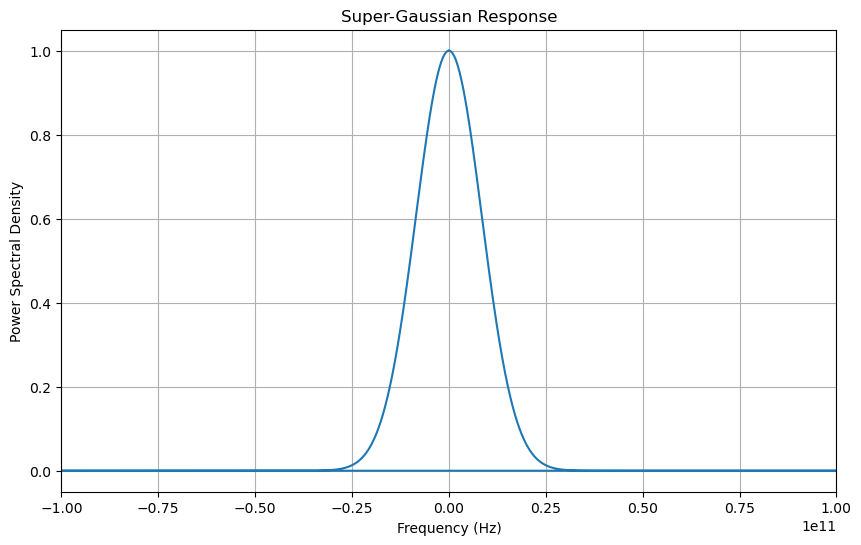

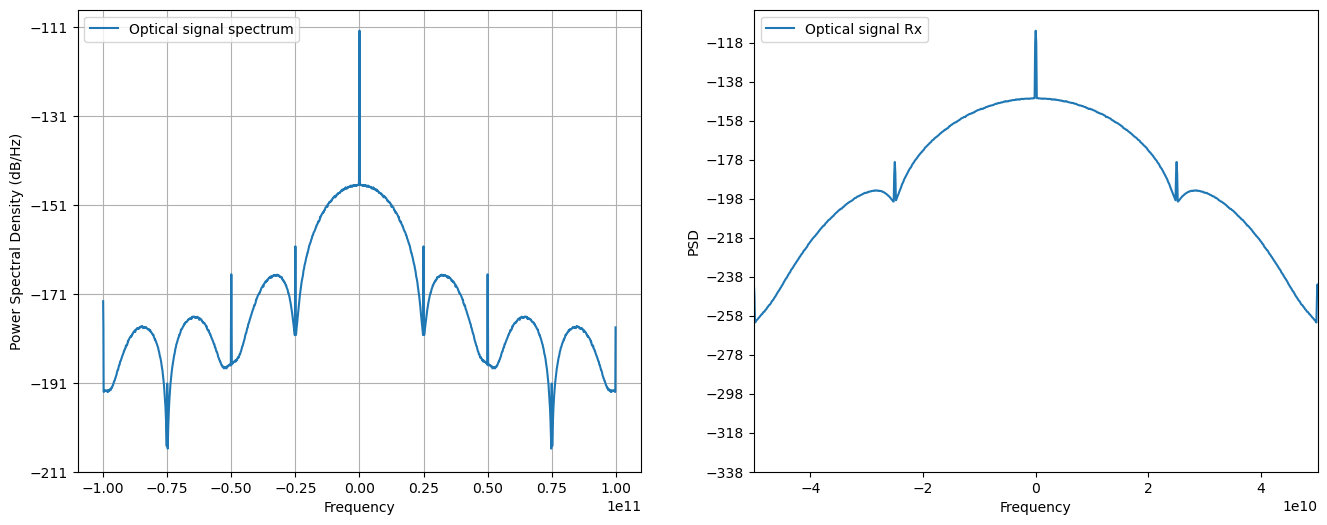

In [5]:
from scipy.fft import fft, ifft, fftfreq


# 1. Definir os parâmetros do canal baseados no artigo
# O artigo varia o B_3dB no eixo X dos gráficos (ex: de 0.1 a 1.5 * Rs)
# e testa a ordem do filtro como 1 e 3.
print(len(signal_optTx))
n_order = 1             # Ordem do supergaussiano (ex: 1 ou 3)
B_3dB = 0.4 * Rs        # Largura de banda em 40% da taxa de símbolos

# 2. Criar o vetor de frequências para o sinal de simulação
#N_samples = len(signal_optTx)
N_samples = len(signal_optTx)
sim_Fs = paramDAC.outFs # A taxa de amostragem do sinal modulado (400 GHz)

# Cria o vetor de frequências correspondente aos bins da FFT
f = fftfreq(N_samples, d=1/sim_Fs)

# 3. Gerar a resposta em frequência do canal
H_ch = superGauss(f, n_order, B_3dB)
plt.figure(figsize=(10, 6))
plt.plot(f, np.abs(H_ch)**2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Super-Gaussian Response')
plt.grid(True)
plt.xlim(-1e11, 1e11)
plt.show()

# 4. Aplicar o filtro ao sinal no domínio da frequência
signal_optTx_fft = np.fft.fft(signal_optTx, N_samples)
signal_optRx_fft = signal_optTx_fft * H_ch

# Retornar o sinal filtrado para o domínio do tempo
signal_optRx = ifft(signal_optRx_fft)

fig, axs = plt.subplots(1, 2, figsize=(16,6))
# plot psd
axs[0].psd(signal_optTx, Fs=paramDAC.outFs, NFFT = 2048, sides='twosided', label = 'Optical signal spectrum')
axs[0].legend(loc='upper left')

axs[1].psd(signal_optRx, Fs = paramDAC.outFs, NFFT = 2048, sides = 'twosided', label = "Optical signal Rx")
axs[1].set_ylabel('PSD')
axs[1].set_xlabel('Frequency')
axs[1].legend(loc='upper left')
axs[1].grid()
axs[1].set_xlim(-0.5e11, 0.5e11)
plt.rcParams['figure.figsize'] = (14, 6)



In [6]:
import logging as logg
from optic.dsp.core import lowPassFIR
import scipy.constants as const
def photodiode(E, param=None):
    """
    Pin photodiode (PD).

    Parameters
    ----------
    E : np.array
        Input optical field.
    param : optic.utils.parameters object, optional
        Parameters of the photodiode model.

        - param.R: photodiode responsivity [A/W][default: 1 A/W]
        - param.Tc: temperature [°C][default: 25°C]
        - param.Id: dark current [A][default: 5e-9 A]
        - param.Ipd_sat: saturation value of the photocurrent [A][default: 5e-3 A]
        - param.RL: impedance load [Ω] [default: 50Ω]
        - param.B: bandwidth [Hz][default: 30e9 Hz]
        - param.Fs: sampling frequency [Hz] [default: None]
        - param.fType: frequency response type [default: 'rect']
        - param.N: number of the frequency resp. filter taps. [default: 255]
        - param.ideal: consider ideal photodiode (i.e. :math:`i_{pd}(t) = R|E(t)|^2`) [default: False]
        - param.shotNoise: add shot noise to photocurrent. [default: True]
        - param.thermalNoise: add thermal noise to photocurrent. [default: True]
        - param.currentSaturation: consider photocurrent saturation. [default: False]
        - param.bandwidthLimitation: consider bandwidth limitation. [default: True]
        - param.seed: seed for the random number generator [default: None]

    Returns
    -------
    ipd : np.array
          photocurrent.

    References
    ----------
    [1] G. P. Agrawal, Fiber-Optic Communication Systems. Wiley, 2021.

    """
    if param is None:
        param = parameters()
    kB = const.value("Boltzmann constant")
    q = const.value("elementary charge")

    # check input parameters
    R = getattr(param, "R", 1)
    Tc = getattr(param, "Tc", 25)
    Id = getattr(param, "Id", 5e-9)
    RL = getattr(param, "RL", 50)
    B = getattr(param, "B", 30e9)
    Ipd_sat = getattr(param, "Ipd_sat", 5e-3)
    N = getattr(param, "N", 255)
    fType = getattr(param, "fType", "rect")
    seed = getattr(param, "seed", None)
    ideal = getattr(param, "ideal", False)
    shotNoise = getattr(param, "shotNoise", True)
    thermalNoise = getattr(param, "thermalNoise", True)
    currentSaturation = getattr(param, "currentSaturation", False)
    bandwidthLimitation = getattr(param, "bandwidthLimitation", True)

    assert R > 0, "PD responsivity should be a positive scalar"

    try:
        nModes = E.shape[1]
    except IndexError:
        nModes = 1

    if nModes > 1:
        ipd = R * np.sum(
            np.abs(E) ** 2, axis=1
        )  # ideal photocurrent with two or more modes
    else:
        ipd = R * E * np.conj(E)  # ideal photocurrent

    if N % 2 == 0:
        N += 1  # make sure N is odd
        logg.warning(
            "Number of filter taps (N) was even, incrementing by one to make it odd."
        )

    if seed is not None:
        np.random.seed(seed)  # set seed for reproducibility

    if not (ideal):
        try:
            Fs = param.Fs
        except AttributeError:
            logg.error("Simulation sampling frequency (Fs) not provided.")

        assert Fs >= 2 * B, "Sampling frequency Fs needs to be at least twice of B."

        if currentSaturation:
            ipd[ipd > Ipd_sat] = Ipd_sat  # saturation of the photocurrent

        if shotNoise:
            # shot noise
            σ2_s = 2 * q * (ipd + Id) * B  # shot noise variance
            print(np.mean(σ2_s))
            Is = np.sqrt(Fs * (σ2_s / (2 * B))) * np.random.normal(0, 1, ipd.shape)
            # add shot noise to photocurrent
            ipd += Is
        if thermalNoise:
            # thermal noise
            T = Tc + 273.15  # temperature in Kelvin
            σ2_T = 4 * kB * T * B / RL  # thermal noise variance
            print(σ2_T)
            It = np.sqrt(Fs * (σ2_T / (2 * B))) * np.random.normal(0, 1, ipd.shape)
            # add thermal noise to photocurrent
            ipd += It
        if bandwidthLimitation:
            # lowpass filtering
            h = lowPassFIR(B, Fs, N, typeF=fType)
            ipd = firFilter(h, ipd)

    return ipd.real

(5.057872005880948e-12-7.561052275476252e-37j)
3.2e-09


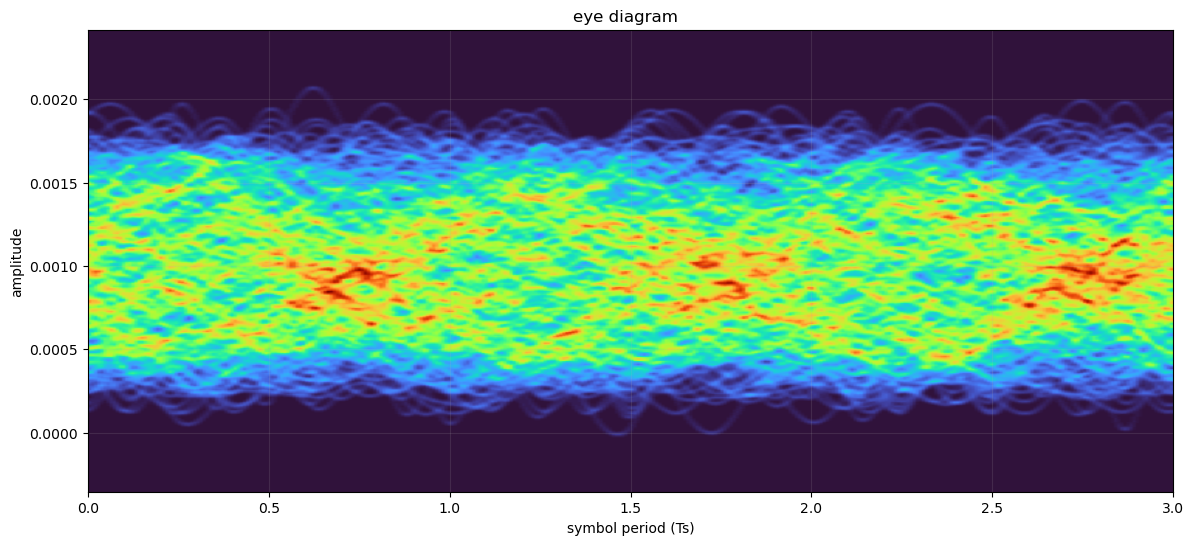

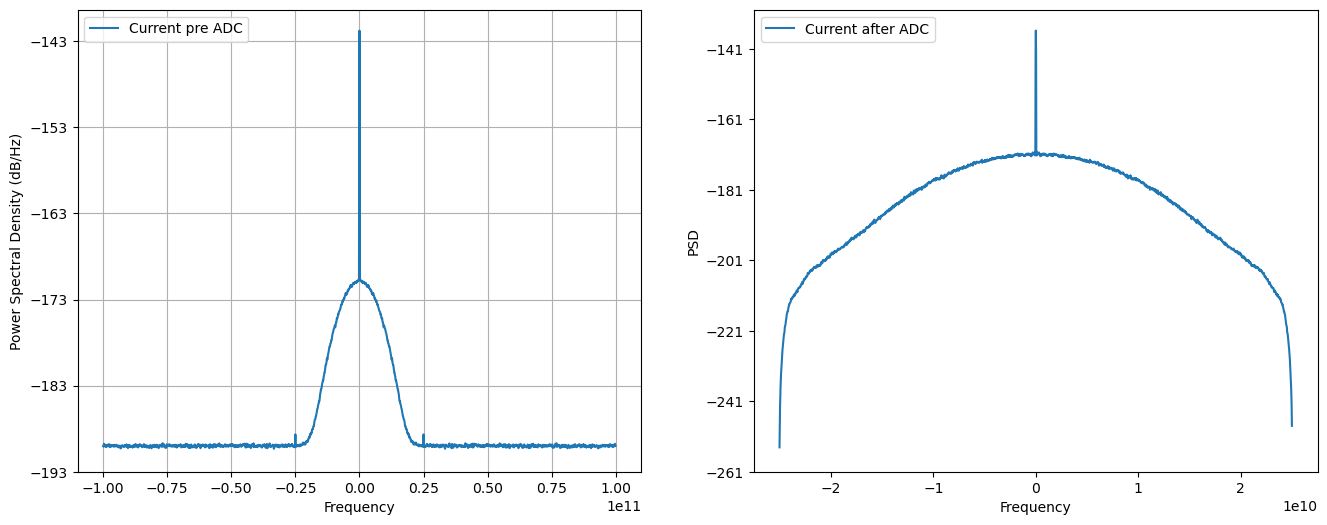

In [7]:
Tc = 70
T_kelvin = Tc + 273.15
paramPD = parameters()
paramPD.R = 1.0                           # Responsividade de 1 A/W (Tabela I do artigo)
paramPD.Tc = Tc                           # Não utilizado (o artigo fixa a PSD do ruído térmico)
paramPD.Id = 10e-9                             # Corrente de escuro zero (omitida no modelo matemático)
paramPD.Ipd_sat = 5e-3                    # Irrelevante (saturação desligada)
paramPD.B = 16e9
paramPD.RL = (4 * kB * T_kelvin) / 2e-19
#paramPD.RL = 50                          # Irrelevante (limitação de banda desligada aqui)
paramPD.Fs = paramDAC.outFs               # Frequência de amostragem global da simulação
paramPD.fType = 'rect'                    # Irrelevante
paramPD.PDN = 255                         # Irrelevante
paramPD.ideal = False                     # False para permitir a injeção de ruídos
paramPD.shotNoise = True                  # O modelo do artigo analisa o Shot Noise
paramPD.thermalNoise = True               # O modelo do artigo analisa o Ruído Térmico
paramPD.currentSaturation = False         # O modelo assume um receptor estritamente linear
paramPD.bandwidthLimitation = False       # IMPORTANTE: Desligado (veja explicação abaixo)
paramPD.seed = 7                          # Qualquer número inteiro

PD_signalRx= photodiode(signal_optRx, paramPD)

eyediagram(np.real(PD_signalRx), len(PD_signalRx), n_dac*SpS ,ptype = 'fancy', plotlabel = "" \
"")
#plt.psd(PD_signalRx, NFFT = 1024, Fs = paramDAC.outFs, sides = 'twosided')

paramAdc = parameters()
paramAdc.inFs = paramDAC.outFs
paramAdc.outFs = Fs
paramAdc.Nbits = paramDAC.nBits
paramAdc.ENOB = paramDAC.ENOB
paramAdc.Vmax = np.max(np.abs(PD_signalRx))
paramAdc.Vmin = -paramAdc.Vmax
paramAdc.AAF = True

if(DAC_ADC):
    sigRx = adc(PD_signalRx, paramAdc)
else:
    sigRx = PD_signalRx
    
sigRx = firFilter(pulse, sigRx)


fig, axs = plt.subplots(1, 2, figsize=(16,6))
# plot psd
axs[0].psd(PD_signalRx, Fs=paramDAC.outFs, NFFT = 2048, sides='twosided', label = 'Current pre ADC')
axs[0].legend(loc='upper left');

axs[1].psd(sigRx, Fs = Fs, NFFT = 2048, sides = 'twosided', label = "Current after ADC")
axs[1].set_ylabel('PSD')
axs[1].set_xlabel('Frequency')
axs[1].legend(loc='upper left')
axs[1].grid()
plt.rcParams['figure.figsize'] = (14, 6)





In [8]:
nTrain = 40000 # number of training symbols
plots = False  # enable/disable plots of equalizer taps and MSE convergence
trainingMode = "fulltime"

paramDec = parameters()
paramDec.SpSin = SpS
paramDec.SpSout = 2

if(DAC_ADC):
    sigRx_eq = sigRx
else:
    sigRx_eq = decimate(sigRx, paramDec)
    

# Apply DFE equalization
paramDFE = parameters()
paramDFE.nTapsFF = 200
paramDFE.nTapsFB = 30
paramDFE.SpS = paramDec.SpSout
paramDFE.mu = 2e-3
paramDFE.nTrain = nTrain
paramDFE.M = M
paramDFE.trainingMode = trainingMode

outDFE, f, b, mseDFE = dfe(sigRx_eq, symb_Tx, paramDFE)
outDFE = pnorm(outDFE)

if plots:
    plt.figure(figsize=(10,3))
    plt.plot(f, 'o-', label='FF taps')
    plt.plot(b, 's-', label='FB taps')
    plt.xlim(0, max(len(f), len(b))-1)
    plt.xlabel('Taps')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.legend()

# Apply FFE equalization
paramFFE = parameters()
paramFFE.nTaps = 200
paramFFE.mu = 2e-3
paramFFE.nTrain = nTrain
paramFFE.SpS = paramDec.SpSout
paramFFE.M = M
paramFFE.trainingMode = trainingMode

outFFE, h, mseFFE = ffe(sigRx_eq, symb_Tx, paramFFE)
outFFE = pnorm(outFFE)

if plots:
    plt.figure(figsize=(10,3))
    plt.plot(h, 'o-', label='FFE taps')
    plt.legend()
    plt.xlim(0, len(h)-1)
    plt.xlabel('Taps')
    plt.ylabel('Amplitude')
    plt.grid()

discard = nTrain

# with FFE equalization
ber_ffe, ser_ffe, snr_ffe = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')

# with DFE equalization
ber_dfe, ser_dfe, snr_dfe = fastBERcalc(outDFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')

print('Performance results:')
print('------------------------------------')
print('Method      |  BER       |  SNR (dB)')
print('------------------------------------')
print(f'FFE         |  {ber_ffe[0]:.2e}  |  {snr_ffe[0]:.2f} ')
print(f'DFE         |  {ber_dfe[0]:.2e}  |  {snr_dfe[0]:.2f} ') 

Performance results:
------------------------------------
Method      |  BER       |  SNR (dB)
------------------------------------
FFE         |  1.32e-02  |  13.66 
DFE         |  6.32e-03  |  14.76 


Potência de Transmissão: 0.001 W
OMA Outer: 0.001 W
OMA Outer (dBm): 0.781 dBm


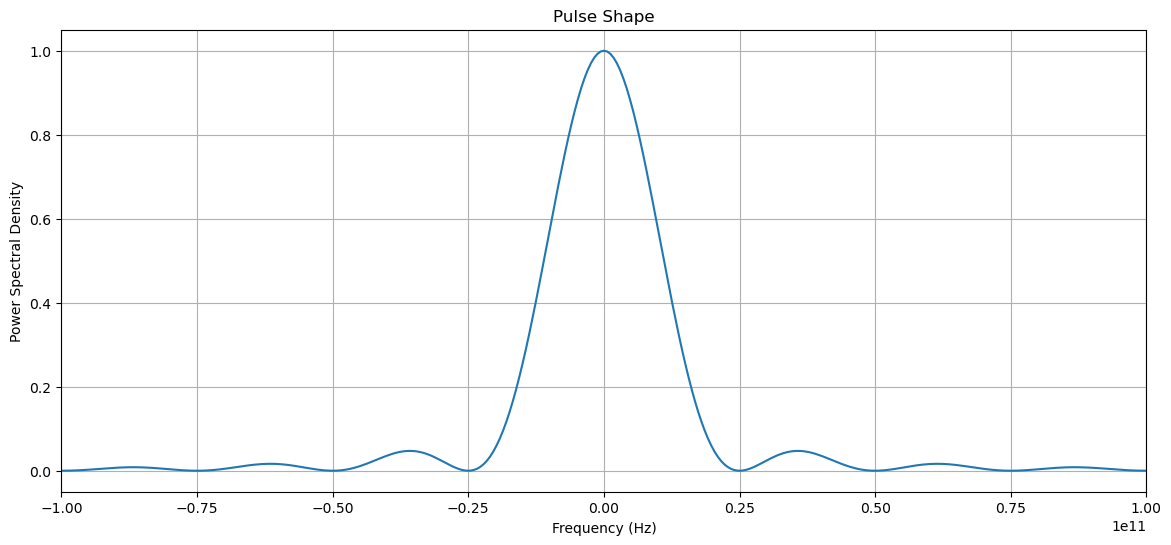

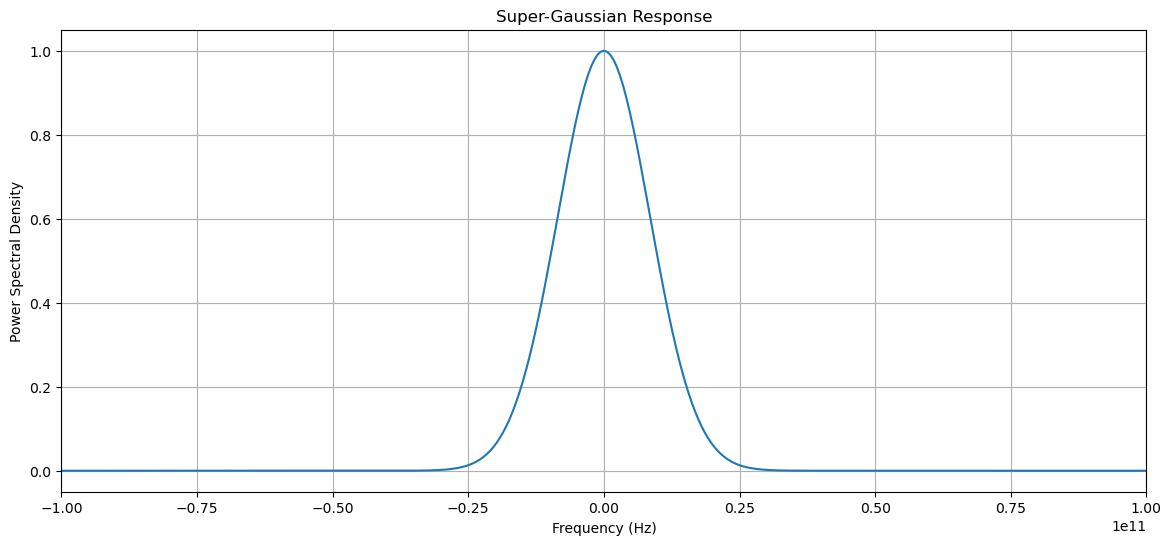

SNR FFE: 14.11 dB | BER FFE: 8.713e-03
SNR DFE: 14.55 dB | BER DFE: 6.353e-03


C:\Users\elmer.farias\AppData\Local\Temp\ipykernel_30368\2616122346.py:59: RuntimeWarning: divide by zero encountered in log10
  SNR_folded_dB = 10 * np.log10(np.abs(SNR_folded))


In [9]:
Rs = 25e9
pTx_dBm = 0
pTx_W = dBm2W(pTx_dBm)
print(f"Potência de Transmissão: {pTx_W:.3f} W")
ER = 6
OMA = 0.78
R = 1
N0 = 2e-19
RIN = -140
M = 4
Tb = 1/(Rs*2)

SIM_N = 10000        # Equivalente a SIM.N
SIM_fmax = 3e12      # Equivalente a SIM.fmax
TX_Ts = 1 / 25e9     

f = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)

# 2. Equivalente a: f_int = linspace(-1/(2*TX.Ts), 1/(2*TX.Ts), SIM.N)
# Aqui usamos o Nyquist para definir a banda de integração da fórmula de Fischer
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)
OMA_outer = calculate_oma_outer(pTx_W, ER)
OMA_Outer_dBm = 10*np.log10(OMA_outer/1e-3)
print(f"OMA Outer: {OMA_outer:.3f} W")
print(f"OMA Outer (dBm): {OMA_Outer_dBm:.3f} dBm")

Ps2 = calculate_ps2(pTx_W, M, OMA_outer)
pTx_mean_squared = np.mean(Ps2**2)

Pulse = np.sinc(2 * Tb * f)
plt.plot(f, np.abs(Pulse)**2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Pulse Shape')
plt.grid(True)
plt.xlim(-1e11, 1e11)
plt.show()

superGauss_response = superGauss(f, n=1, B_3dB=0.4*Rs)
plt.plot(f, np.abs(superGauss_response)**2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Super-Gaussian Response')
plt.grid(True)
plt.xlim(-1e11, 1e11)
plt.show()

S_RIN = calc_S_RIN(Ps2, RIN, f)
S_th = calc_S_th(N0, f)
S_shot = calc_S_shot(pTx_W, R, 1, 1, f)

SuperGauss_response = superGauss(f, n=1, B_3dB=0.4*Rs)
superGaussSquared = np.abs(SuperGauss_response)**2

S_N_total = calc_S_N(S_RIN, S_shot, S_th, superGaussSquared, 10, False)
S_N_f = get_spectral_snr(f, OMA_outer, Rs, Pulse, SuperGauss_response, S_N_total)
SNR_folded = SNR_Folding(S_N_f, f, mu=2, Rs=Rs)

SNR_folded_dB = 10 * np.log10(np.abs(SNR_folded))
SNR_f_interp_dB = np.interp(f_int, f, SNR_folded_dB)
SNR_f_Nyquist = 10**(SNR_f_interp_dB / 10)  # Volta para escala linear

# 7. Integrais de Fischer (FFE / DFE) usando np.trapezoid
# FFE
SNR_int_ffe = np.trapezoid(1 / (SNR_f_Nyquist + 1), x=f_int)
SNR_FFE_dB = 10 * np.log10(1 / (TX_Ts * SNR_int_ffe) - 1)
SNR_FFE_linear = 10**(SNR_FFE_dB / 10)

# DFE
SNR_int_dfe = np.trapezoid(np.log(SNR_f_Nyquist + 1), x=f_int)
SNR_DFE_dB = 10 * np.log10(np.exp(TX_Ts * SNR_int_dfe) - 1)
SNR_DFE_linear = 10**(SNR_DFE_dB / 10)

# 8. Estimativa Global de BER (Para fins de comparação rápida)
BER_FFE_global = ber_from_snr_m_pam(SNR_FFE_linear, M)
BER_DFE_global = ber_from_snr_m_pam(SNR_DFE_linear, M)

print(f"SNR FFE: {SNR_FFE_dB:.2f} dB | BER FFE: {BER_FFE_global:.3e}")
print(f"SNR DFE: {SNR_DFE_dB:.2f} dB | BER DFE: {BER_DFE_global:.3e}")

C:\Users\elmer.farias\AppData\Local\Temp\ipykernel_30368\1136636093.py:61: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
C:\Users\elmer.farias\AppData\Local\Temp\ipykernel_30368\1136636093.py:83: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)


Iniciando varredura analítica. Isso pode levar alguns segundos...


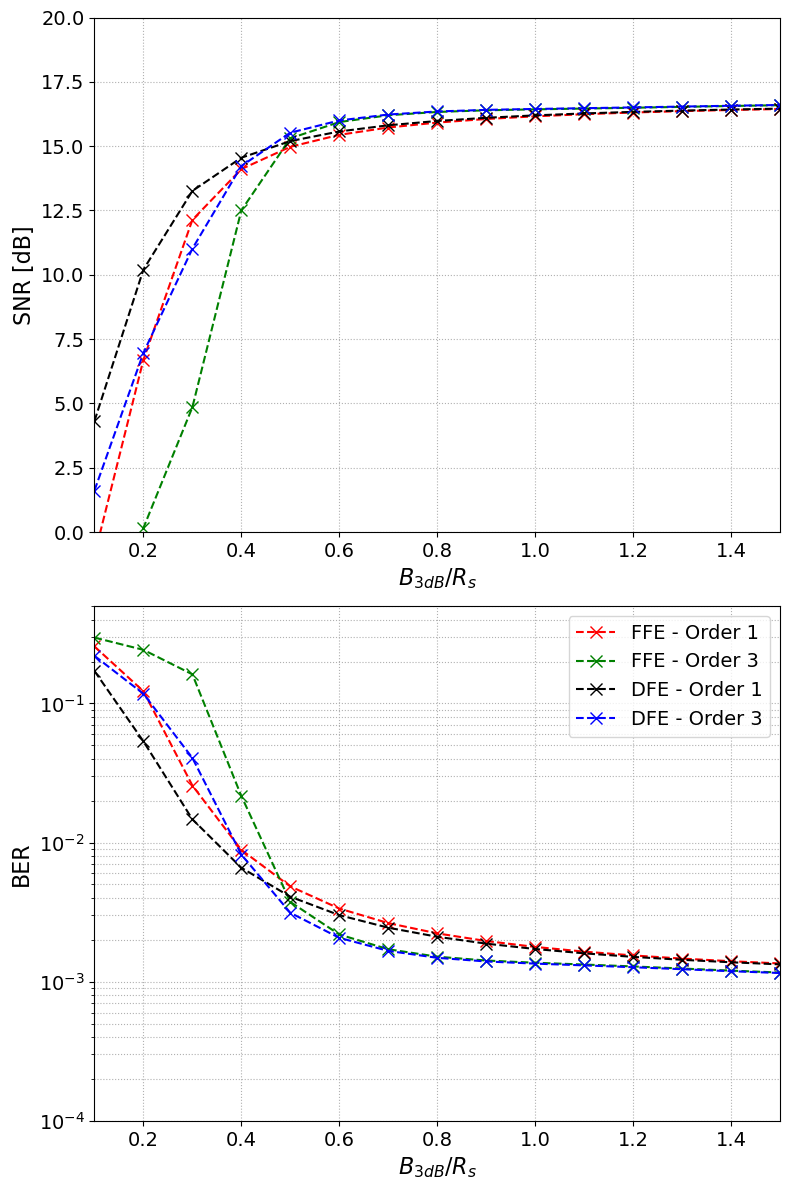

In [10]:

# 1. PARÂMETROS GLOBAIS E CONSTANTES
Rs = 25e9
pTx_dBm = 0
pTx_W = 10**(pTx_dBm/10) * 1e-3
ER = 6
R = 1.0
N0 = 2e-19
RIN = -140
M = 4
Tb = 1 / (Rs * 2)
TX_Ts = 1 / Rs

SIM_N = 10000        
SIM_fmax = 3e12      

# Eixos de frequência
f = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)

# Cálculo da OMA e Níveis do PAM-4
OMA_outer = calculate_oma_outer(pTx_W, ER)
Ps2 = calculate_ps2(pTx_W, M, OMA_outer)
#pTx_mean_squared = np.mean(Ps2**2)

# Resposta do Pulso e Ruídos Fixos (Não dependem do filtro do canal)
Pulse = np.sinc(2 * Tb * f)
S_th = calc_S_th(N0, f)
S_shot = calc_S_shot(pTx_W, R, 1, 1, f) # Assumindo PIN sem ganho extra

# 2. PREPARAÇÃO DOS LOOPS (VARREDURA)
b_rs_ratios = np.arange(0.1, 1.6, 0.1) # Vai de 0.1 até 1.5
orders = [1, 3]

# Dicionários para armazenar os resultados para cada ordem
results = {
    1: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []},
    3: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []}
}

print("Iniciando varredura analítica. Isso pode levar alguns segundos...")

# 3. LOOP PRINCIPAL
for n in orders:
    for ratio in b_rs_ratios:
        B_3dB = ratio * Rs
        
        # 1. Resposta do Canal
        H_ch = superGauss(f, n=n, B_3dB=B_3dB)
        H_ch_sq = np.abs(H_ch)**2
        
        # 2. Ruído Total Global (Para plotar a curva de SNR Global)
        S_RIN_global = calc_S_RIN(Ps2, RIN, f)
        S_N_total = calc_S_N(S_RIN_global, S_shot, S_th, H_ch_sq, 10, False)
        
        # 3. SNR Espectral (Global)
        S_N_f = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_total)
        S_N_f = np.nan_to_num(S_N_f, nan=0.0)
        
        # 4. Folding e Integrais Globais (Para o Gráfico de SNR)
        SNR_folded = SNR_Folding(S_N_f, f, mu=2, Rs=Rs)
        SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        snr_dfe_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp + 1), x=f_int)) - 1
        
        results[n]['snr_ffe'].append(10 * np.log10(snr_ffe_lin))
        results[n]['snr_dfe'].append(10 * np.log10(snr_dfe_lin))
        
        # 5. Loop Heurístico "Olho-por-Olho" (Para o Gráfico de BER)
        ber_ffe_eyes = []
        ber_dfe_eyes = []
        
        for i in range(M - 1):
            # Recalcula o RIN focado na potência dos 2 níveis que formam ESTE olho
            S_RIN_eye = calc_S_RIN(Ps2[i : i+2], RIN, f)
            S_N_eye = calc_S_N(S_RIN_eye, S_shot, S_th, H_ch_sq, 10, False)
            
            # SNR e Folding deste olho
            S_N_f_eye = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_eye)
            S_N_f_eye = np.nan_to_num(S_N_f_eye, nan=0.0)
            
            SNR_folded_eye = SNR_Folding(S_N_f_eye, f, mu=2, Rs=Rs)
            SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)
            
            # Equalizadores
            snr_ffe_eye_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp_eye + 1), x=f_int)) - 1
            snr_dfe_eye_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp_eye + 1), x=f_int)) - 1
            
            ber_ffe_eyes.append(ber_from_snr_m_pam(snr_ffe_eye_lin, M))
            ber_dfe_eyes.append(ber_from_snr_m_pam(snr_dfe_eye_lin, M))
            
        # A BER final é a média das BERs dos 3 olhos
        results[n]['ber_ffe'].append(np.mean(ber_ffe_eyes))
        results[n]['ber_dfe'].append(np.mean(ber_dfe_eyes))

# 4. PLOTAGEM DOS GRÁFICOS (Idêntico ao Artigo)
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# Gráfico 1: SNR
axs[0].plot(b_rs_ratios, results[1]['snr_ffe'], 'r--x', label='FFE - Order 1', markersize=8)
axs[0].plot(b_rs_ratios, results[3]['snr_ffe'], 'g--x', label='FFE - Order 3', markersize=8)
axs[0].plot(b_rs_ratios, results[1]['snr_dfe'], 'k--x', label='DFE - Order 1', markersize=8)
axs[0].plot(b_rs_ratios, results[3]['snr_dfe'], 'b--x', label='DFE - Order 3', markersize=8)
axs[0].set_xlabel(r'$B_{3dB}/R_s$', fontsize=16)
axs[0].set_ylabel('SNR [dB]', fontsize=16)
axs[0].set_ylim(0, 20)
axs[0].set_xlim(0.1, 1.5)
axs[0].grid(True, linestyle=':')
axs[0].tick_params(axis='both', labelsize=14)

# Gráfico 2: BER
axs[1].semilogy(b_rs_ratios, results[1]['ber_ffe'], 'r--x', label='FFE - Order 1', markersize=8)
axs[1].semilogy(b_rs_ratios, results[3]['ber_ffe'], 'g--x', label='FFE - Order 3', markersize=8)
axs[1].semilogy(b_rs_ratios, results[1]['ber_dfe'], 'k--x', label='DFE - Order 1', markersize=8)
axs[1].semilogy(b_rs_ratios, results[3]['ber_dfe'], 'b--x', label='DFE - Order 3', markersize=8)
axs[1].set_xlabel(r'$B_{3dB}/R_s$', fontsize=16)
axs[1].set_ylabel('BER', fontsize=16)
axs[1].set_ylim(1e-4, 0.5)
axs[1].set_xlim(0.1, 1.5)
axs[1].grid(True, linestyle=':', which='both')
axs[1].tick_params(axis='both', labelsize=14)
axs[1].legend(fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()